### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
from nltk import corpus
import string
from wordcloud import WordCloud

In [85]:
from sklearn.feature_extraction import text
from sklearn.metrics import pairwise
from scipy import stats

### Step 2: Load Data

In [3]:
df = pd.read_csv('./data/tedx_datase.csv')

In [4]:
df.shape

(4467, 7)

In [5]:
df.head()

,idx,main_speaker,title,details,posted,url,num_views
0,8d2005ec35280deb6a438dc87b225f89,Alexandra Auer,The intangible effects of walls,More barriers exist now than at the end of Wor...,Posted Apr 2020,https://www.ted.com/talks/alexandra_auer_the_i...,NaN
1,b3072cd11f40eb57fd259555264476c6,Elizabeth Gilbert,It's OK to feel overwhelmed. Here's what to do...,If you're feeling anxious or fearful during th...,Posted Apr 2020,https://www.ted.com/talks/elizabeth_gilbert_it...,NaN
2,4adc9fee977fa04c357ed4c9b52aa3cc,Butterscotch,"""Accept Who I Am""","Firing off her formidable beatboxing skills, m...",Posted Apr 2020,https://www.ted.com/talks/butterscotch_accept_...,0.0
3,59c641a72b495d522a7932145d6c02b3,Ethan Lisi,What it's really like to have autism,"""Autism is not a disease; it's just another wa...",Posted Apr 2020,https://www.ted.com/talks/ethan_lisi_what_it_s...,NaN
4,d227f2faf6ec185e54436d86463f499b,Daniel Finkel,Can you solve the sea monster riddle?,"According to legend, once every thousand years...",Posted Apr 2020,https://www.ted.com/talks/daniel_finkel_can_yo...,0.0


### Step 3: Exploaring Data

In [12]:
df['year'] = df['posted'].str.split(' ').str[-1].astype('int')

#### Basic Info

In [22]:
df.describe()

,num_views,year
count,209.0,4467.000000
mean,0.0,2014.499888
std,0.0,3.800345
min,0.0,2006.000000
25%,0.0,2012.000000
50%,0.0,2015.000000
75%,0.0,2018.000000
max,0.0,2020.000000


In [23]:
feature_info = pd.DataFrame(
    {
        'null': df.isnull().sum(),
        'null(%)': round(df.isnull().sum() / len(df), 2),
        'unique': df.nunique(),
        'type': df.dtypes
    }
)

In [24]:
feature_info

,null,null(%),unique,type
idx,0,0.00,4467,object
main_speaker,1,0.00,3732,object
title,0,0.00,4467,object
details,0,0.00,4467,object
posted,0,0.00,166,object
url,0,0.00,4467,object
num_views,4258,0.95,1,float64
year,0,0.00,15,int64
month,0,0.00,12,object


#### Feature Distribution

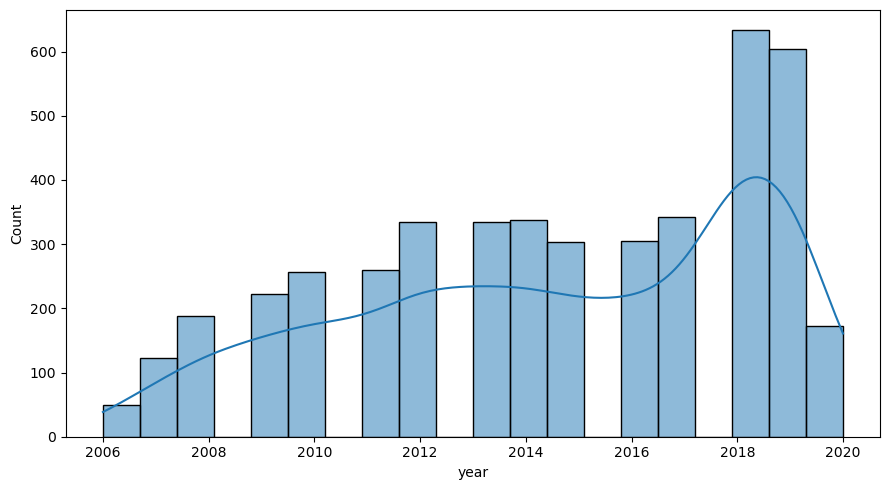

In [32]:
plt.figure(figsize=(9, 5))
sns.histplot(x='year', data=df, kde=True)
plt.tight_layout()

### Step 4: Exploaring Data

#### Headling Missing Value

In [37]:
df = df.drop('num_views', axis=1)

In [40]:
df = df.dropna(ignore_index=True)

#### Text Preprocessing

In [43]:
stop_words = corpus.stopwords.words('english')

In [46]:
df['details'] = df['title'] + ' ' + df['details']

In [48]:
df['details'] = df['details'].str.lower()

In [50]:
df['details'] = df['details'].map(
    lambda x: ' '.join(token for token in x.split() if token not in stop_words)
)

#### Remove Punctuations

In [57]:
signal = str.maketrans('', '', string.punctuation)

In [59]:
df['details'] = df['details'].map(lambda x: x.translate(signal))

#### World Cloud

In [60]:
details_corpus = ' '.join(df['details'])

In [67]:
word_cloud = WordCloud(
    width=800,
    height=400,
    random_state=21,
    max_words=1000,
)

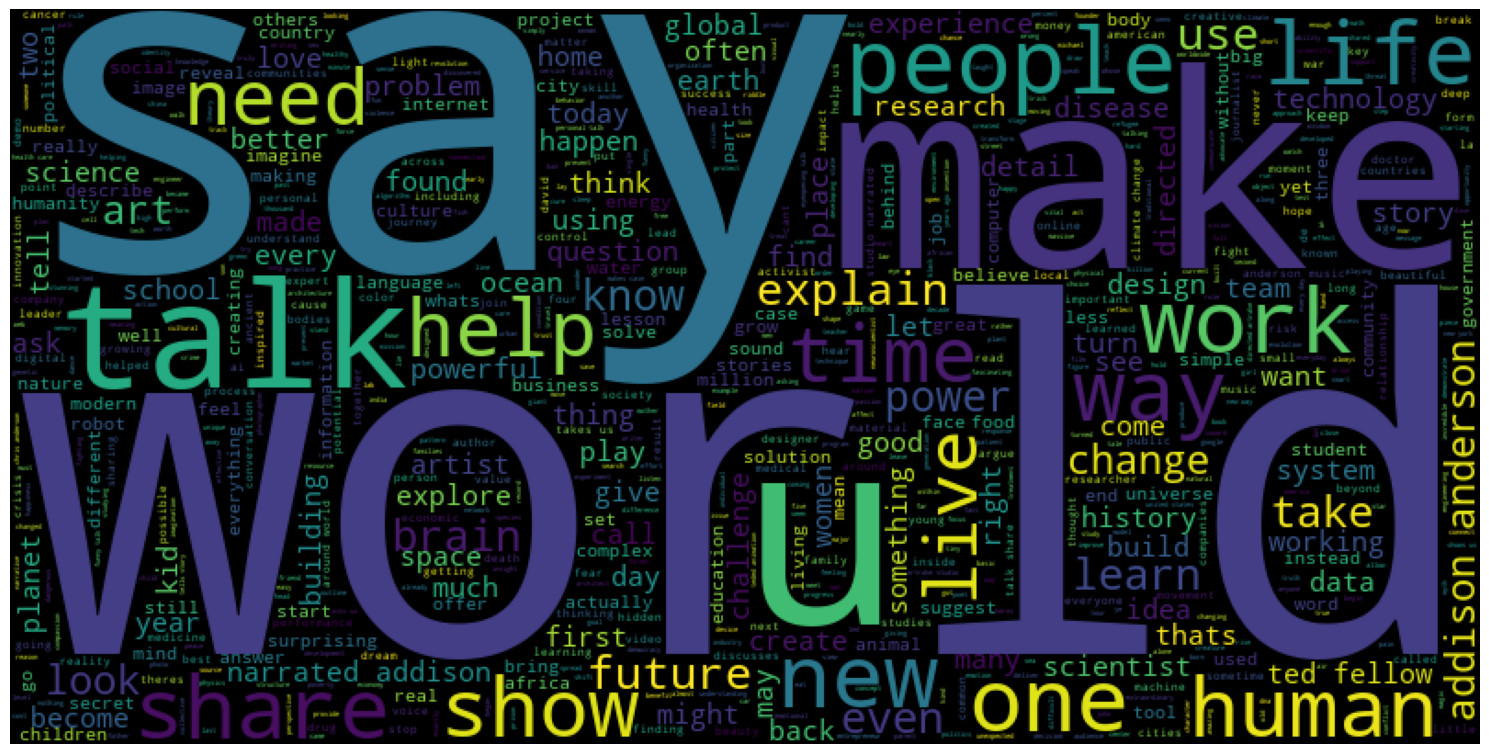

In [68]:
plt.figure(figsize=(15, 10))
plt.imshow(word_cloud.generate(details_corpus))
plt.axis('off')
plt.tight_layout()

#### Vectorizer

In [71]:
vectorizer = text.TfidfVectorizer()

In [72]:
vectorizer.fit(df['details'])

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


### Step 5: Recommender System

In [114]:
def get_similarities(talk_content, data):
    talk_vector = vectorizer.transform(talk_content).toarray()
    cos, pea = list(), list()
    for _, row in data.iterrows():
        details = row['details']
        df_vector = vectorizer.transform([details]).toarray()
        cos_sim = pairwise.cosine_similarity(talk_vector, df_vector)[0][0]
        pea_sim = stats.pearsonr(talk_vector.squeeze(), df_vector.squeeze())[0]
        cos.append(cos_sim)
        pea.append(pea_sim)
    return cos, pea

In [124]:
def recommend_talks(talk_content, data):
    data['cos_sim'], data['pea_sim'] = get_similarities(talk_content, data)
    res = data.sort_values(
        by=['cos_sim', 'pea_sim'], 
        ascending=[False, False]
    )
    return res[['main_speaker', 'title', 'details']].head()

In [129]:
talk_content = ['Time Management and working hard to become successful in life']
recommend_talks(talk_content, df)

,main_speaker,title,details
1758,Laura Vanderkam,How to gain control of your free time,gain control free time 168 hours week find tim...
2172,Philip Krinks,Finding your personal mission in life,finding personal mission life philip krinks ha...
66,Fang Ruan,Management lessons from Chinese business and p...,management lessons chinese business philosophy...
2075,Jessica Shortall,The US needs paid family leave — for the sake ...,us needs paid family leave — sake future need ...
2445,Susan Etlinger,What do we do with all this big data?,big data set data make feel comfortable succes...


In [131]:
talk_content = ['Climate change and impact on the health. How can we change this world by reducing carbon footprints?']
recommend_talks(talk_content, df)

,main_speaker,title,details
582,Sarvesh Subramanian,An app that predicts the impact of global clim...,app predicts impact global climate change deep...
3301,James Hansen,Why I must speak out about climate change,must speak climate change top climate scientis...
377,Britt Wray,How climate change affects your mental health,climate change affects mental health for thats...
2585,Gavin Schmidt,The emergent patterns of climate change,emergent patterns climate change cant understa...
562,Joanne Chory,How supercharged plants could slow climate change,supercharged plants could slow climate change ...
